In [15]:
# 🟢 1️⃣ IMPORTS & SETUP
import os
import pandas as pd
import numpy as np
import cv2
from ultralytics import YOLO
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Paths
BASE_PATH = r"D:\project\traffic-congestion-prediction\dataset\Final Dataset"
TRAIN_DIR = os.path.join(BASE_PATH, "training")
VAL_DIR = os.path.join(BASE_PATH, "validation")
TEST_DIR = os.path.join(BASE_PATH, "testing")

In [16]:
# 🟢 2️⃣ YOLOv8 VEHICLE DETECTION & COUNTING
yolo_model = YOLO("yolov8n.pt")  # ✅ renamed

output_csv = os.path.join(BASE_PATH, "vehicle_counts.csv")

def count_vehicles_in_folder(folder_path, label):
    data = []
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        results = yolo_model(img_path, verbose=False)
        vehicle_count = 0
        for r in results:
            for c in r.boxes.cls:
                if int(c) in [2, 3, 5, 7]:  # car, motorbike, bus, truck
                    vehicle_count += 1
        data.append({"image": img_path, "vehicles": vehicle_count, "label": label})
    return data

# Run for all splits
all_data = []
splits = ["training", "validation", "testing"]
for split in splits:
    split_path = os.path.join(BASE_PATH, split)
    for label in os.listdir(split_path):
        folder_path = os.path.join(split_path, label)
        all_data += count_vehicles_in_folder(folder_path, label)

df = pd.DataFrame(all_data)
df.to_csv(output_csv, index=False)
print("✅ Vehicle counts saved to:", output_csv)
df.head()

✅ Vehicle counts saved to: D:\project\traffic-congestion-prediction\dataset\Final Dataset\vehicle_counts.csv


,image,vehicles,label
0,D:\project\traffic-congestion-prediction\datas...,0,Empty
1,D:\project\traffic-congestion-prediction\datas...,0,Empty
2,D:\project\traffic-congestion-prediction\datas...,0,Empty
3,D:\project\traffic-congestion-prediction\datas...,0,Empty
4,D:\project\traffic-congestion-prediction\datas...,0,Empty


In [17]:
# 🟢 3️⃣ CNN MODEL (MobileNetV2) TRAINING
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Build Model
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

cnn_model = models.Sequential([  # ✅ renamed
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_gen.num_classes, activation='softmax')
])

cnn_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Train
history = cnn_model.fit(train_gen, validation_data=val_gen, epochs=15)
cnn_model.save("traffic_congestion_model.h5")
print("✅ Model saved as traffic_congestion_model.h5")

Found 3378 images belonging to 5 classes.
Found 340 images belonging to 5 classes.


d:\project\traffic-congestion-prediction\myenv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 123s 545ms/step - accuracy: 0.4861 - loss: 1.2794 - val_accuracy: 0.6588 - val_loss: 0.8399
Epoch 2/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 124s 588ms/step - accuracy: 0.6027 - loss: 0.9377 - val_accuracy: 0.7382 - val_loss: 0.7326
Epoch 3/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 134s 631ms/step - accuracy: 0.6477 - loss: 0.8490 - val_accuracy: 0.7647 - val_loss: 0.6582
Epoch 4/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 111s 484ms/step - accuracy: 0.6699 - loss: 0.7650 - val_accuracy: 0.7647 - val_loss: 0.6393
Epoch 5/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 53s 248ms/step - accuracy: 0.7007 - loss: 0.7294 - val_accuracy: 0.7382 - val_loss: 0.6356
Epoch 6/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 109s 513ms/step - accuracy: 0.7072 - loss: 0.6990 - val_accuracy: 0.7735 - val_loss: 0.6055
Epoch 7/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 134s 633ms/step - accuracy: 0.7090 - loss: 0.6865 - val_accuracy: 0.7706 - val_loss: 0.6028
Epoch 8/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 134s 633ms/step - accuracy: 0.7173 - 

✅ Model saved as traffic_congestion_model.h5


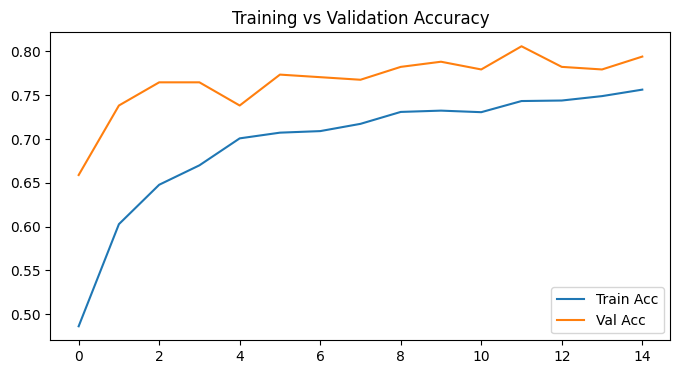

In [18]:
# 🟢 4️⃣ VISUALIZE TRAINING RESULTS
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

In [19]:
# 🟢 5️⃣ EVALUATE ON TEST DATA
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_acc = cnn_model.evaluate(test_gen)
print(f"✅ Test Accuracy: {test_acc*100:.2f}%")

Found 320 images belonging to 5 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 218ms/step - accuracy: 0.8156 - loss: 0.4865
✅ Test Accuracy: 81.56%


In [20]:
# 🟢 6️⃣ SINGLE IMAGE PREDICTION FUNCTION
class_labels = ["Empty", "Low", "Medium", "High", "Traffic Jam"]

def predict_congestion(img_path):
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    preds = cnn_model.predict(img_array)  # ✅ use cnn_model
    predicted_label = class_labels[np.argmax(preds)]
    confidence = np.max(preds)
    print(f"Prediction: {predicted_label} (Confidence: {confidence:.2f})")
    return predicted_label

# Test Example
sample_image = os.path.join(TEST_DIR, "Medium", os.listdir(os.path.join(TEST_DIR, "Medium"))[0])
predict_congestion(sample_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: High (Confidence: 0.56)


'High'

In [21]:
# 🟢 7️⃣ OPTIONAL: DISPLAY YOLO DETECTION ON ONE IMAGE
img_path = sample_image
results = yolo_model(img_path, verbose=False)  # ✅ use yolo_model
for r in results:
    img = r.plot()
    cv2.imshow("YOLOv8 Vehicle Detection", img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

print(type(yolo_model))
print(type(cnn_model))

<class 'ultralytics.models.yolo.model.YOLO'>
<class 'keras.src.models.sequential.Sequential'>
